# Task 3: Generation of Parameter Sets for HMM

**HMM config:** 4 states (S={1,2,3,4}), 3 observation symbols (ν={1,2,3}), π={1,0,0,0}

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

NUMERIC_SEED = 200669132     # student ID

print(f'Seed used: {NUMERIC_SEED}')
rng = np.random.default_rng(NUMERIC_SEED)

N_STATES = 4
N_OBS    = 3

Seed used: 200669132


## Generate P and B matrices

In [2]:
# Step 1: P matrix (4x4) - draw random, normalize rows
P_raw = rng.random((N_STATES, N_STATES))
P     = P_raw / P_raw.sum(axis=1, keepdims=True)

# Step 2: B matrix (4x3) - draw random, normalize rows
B_raw = rng.random((N_STATES, N_OBS))
B     = B_raw / B_raw.sum(axis=1, keepdims=True)

# Initial distribution
pi = np.array([1.0, 0.0, 0.0, 0.0])

print('True P (transition matrix):')
print(pd.DataFrame(P.round(4), index=[f'S{i+1}→' for i in range(4)],
                               columns=[f'S{j+1}' for j in range(4)]).to_string())
print(f'Row sums: {P.sum(axis=1).round(6)}')

print('\nTrue B (emission matrix):')
print(pd.DataFrame(B.round(4), index=[f'State {i+1}' for i in range(4)],
                               columns=[f'Obs {k+1}' for k in range(3)]).to_string())
print(f'Row sums: {B.sum(axis=1).round(6)}')

print(f'\nπ = {pi}')

True P (transition matrix):
         S1      S2      S3      S4
S1→  0.3500  0.1620  0.3469  0.1411
S2→  0.1476  0.0354  0.5278  0.2892
S3→  0.3466  0.3214  0.0521  0.2798
S4→  0.0550  0.4127  0.1585  0.3739
Row sums: [1. 1. 1. 1.]

True B (emission matrix):
          Obs 1   Obs 2   Obs 3
State 1  0.4129  0.4213  0.1657
State 2  0.4246  0.2744  0.3011
State 3  0.2476  0.6181  0.1343
State 4  0.4207  0.1122  0.4672
Row sums: [1. 1. 1. 1.]

π = [1. 0. 0. 0.]


## Step 3 - Simulate 1000 Observations

Generated 1000 observations
First 30 obs   : [1, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 3, 1, 1, 3, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 3]
First 30 states: [1, 1, 3, 1, 3, 1, 1, 4, 2, 1, 1, 3, 2, 3, 2, 3, 2, 4, 2, 3, 1, 3, 1, 3, 2, 4, 2, 3, 4, 2]
Obs counts   : {1: np.int64(371), 2: np.int64(346), 3: np.int64(283)}
State counts : {1: np.int64(205), 2: np.int64(255), 3: np.int64(259), 4: np.int64(281)}


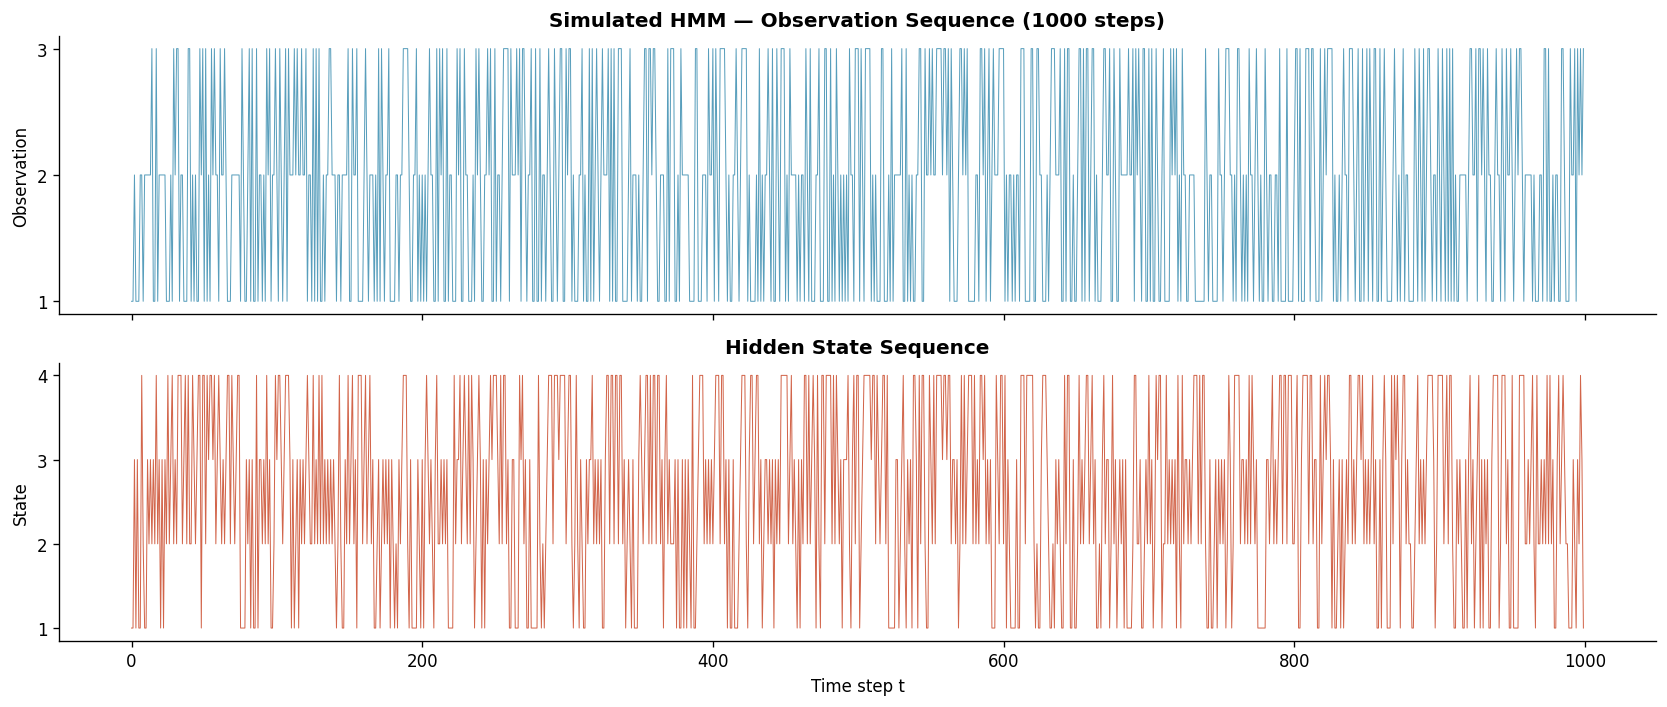

In [3]:
def simulate_hmm(P, B, pi, T, rng):
    N = P.shape[0]
    states = np.zeros(T, dtype=int)
    obs    = np.zeros(T, dtype=int)
    states[0] = np.searchsorted(np.cumsum(pi), rng.random())
    obs[0]    = np.searchsorted(np.cumsum(B[states[0]]), rng.random())
    for t in range(1, T):
        states[t] = np.searchsorted(np.cumsum(P[states[t-1]]), rng.random())
        obs[t]    = np.searchsorted(np.cumsum(B[states[t]]),    rng.random())
    return states + 1, obs + 1   # 1-based

T = 1000
states_true, obs_seq = simulate_hmm(P, B, pi, T, rng)

print(f'Generated {T} observations')
print(f'First 30 obs   : {obs_seq[:30].tolist()}')
print(f'First 30 states: {states_true[:30].tolist()}')
print(f'Obs counts   : { {k:(obs_seq==k).sum() for k in [1,2,3]} }')
print(f'State counts : { {k:(states_true==k).sum() for k in [1,2,3,4]} }')

fig, axes = plt.subplots(2,1,figsize=(14,6),sharex=True)
axes[0].plot(obs_seq,    color='#2E86AB',linewidth=0.6,alpha=0.8)
axes[0].set_ylabel('Observation'); axes[0].set_yticks([1,2,3])
axes[0].set_title('Simulated HMM — Observation Sequence (1000 steps)',fontweight='bold')
axes[1].plot(states_true,color='#C73E1D',linewidth=0.6,alpha=0.8)
axes[1].set_ylabel('State'); axes[1].set_yticks([1,2,3,4])
axes[1].set_title('Hidden State Sequence',fontweight='bold')
axes[1].set_xlabel('Time step t')
plt.tight_layout()
plt.savefig('t3_simulation.png',dpi=150,bbox_inches='tight')
plt.show()

## Task 3 — Estimate p(O|λ): Forward Algorithm

Calculate the probability that **O = {1,2,3,3,1,2,3,3,1,2,3,3}** was produced by this HMM.

In [4]:
def forward_log(O, P, B, pi):
    T, N = len(O), P.shape[0]
    O_idx = [o-1 for o in O]
    log_alpha = np.full((T,N), -np.inf)
    log_alpha[0] = np.log(pi+1e-300) + np.log(B[:,O_idx[0]]+1e-300)
    for t in range(1,T):
        for j in range(N):
            log_alpha[t,j] = (np.logaddexp.reduce(log_alpha[t-1]+np.log(P[:,j]+1e-300))
                              + np.log(B[j,O_idx[t]]+1e-300))
    return np.logaddexp.reduce(log_alpha[-1]), log_alpha

O_given  = [1,2,3,3,1,2,3,3,1,2,3,3]
log_p, _ = forward_log(O_given, P, B, pi)

print(f'Observation sequence : O = {O_given}')
print(f'log p(O|λ)           : {log_p:.6f}')
print(f'p(O|λ)               : {np.exp(log_p):.6e}')
print()
print('Interpretation: This is the total probability that the HMM with the given')
print('parameters λ=(P,B,π) produced this exact 12-symbol sequence, summed over')
print('all 4^12 possible hidden state paths.')

Observation sequence : O = [1, 2, 3, 3, 1, 2, 3, 3, 1, 2, 3, 3]
log p(O|λ)           : -13.558633
p(O|λ)               : 1.292886e-06

Interpretation: This is the total probability that the HMM with the given
parameters λ=(P,B,π) produced this exact 12-symbol sequence, summed over
all 4^12 possible hidden state paths.


## Task 3.1

Find Q* for **O = {1,2,3,3,1,2,3,3,1,2,3}**.

Observation sequence        : [1, 2, 3, 3, 1, 2, 3, 3, 1, 2, 3]
Most probable state sequence: [1, 3, 4, 4, 2, 3, 4, 4, 2, 3, 4]
log P(Q*,O|λ)               : -17.741919
P(Q*,O|λ)                   : 1.971436e-08
 t  O_t  Q*_t
 1    1     1
 2    2     3
 3    3     4
 4    3     4
 5    1     2
 6    2     3
 7    3     4
 8    3     4
 9    1     2
10    2     3
11    3     4


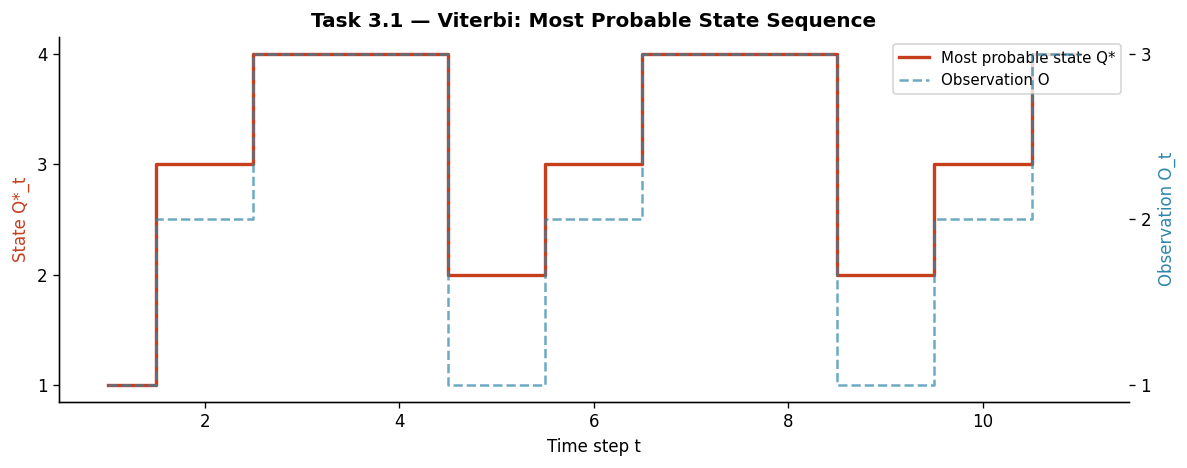

In [5]:
def viterbi(O, P, B, pi):
    T, N = len(O), P.shape[0]
    O_idx = [o-1 for o in O]
    log_d = np.full((T,N),-np.inf)
    psi   = np.zeros((T,N), dtype=int)
    log_d[0] = np.log(pi+1e-300)+np.log(B[:,O_idx[0]]+1e-300)
    for t in range(1,T):
        for j in range(N):
            sc = log_d[t-1]+np.log(P[:,j]+1e-300)
            psi[t,j]   = np.argmax(sc)
            log_d[t,j] = sc[psi[t,j]]+np.log(B[j,O_idx[t]]+1e-300)
    Q = np.zeros(T, dtype=int)
    Q[-1] = np.argmax(log_d[-1])
    for t in range(T-2,-1,-1):
        Q[t] = psi[t+1,Q[t+1]]
    return Q+1, log_d[-1,Q[-1]]

O_v = [1,2,3,3,1,2,3,3,1,2,3]
Q_opt, log_q = viterbi(O_v, P, B, pi)

print(f'Observation sequence        : {O_v}')
print(f'Most probable state sequence: {Q_opt.tolist()}')
print(f'log P(Q*,O|λ)               : {log_q:.6f}')
print(f'P(Q*,O|λ)                   : {np.exp(log_q):.6e}')

df_v = pd.DataFrame({'t':range(1,len(O_v)+1),'O_t':O_v,'Q*_t':Q_opt.tolist()})
print(df_v.to_string(index=False))

fig,ax = plt.subplots(figsize=(10,4))
t_idx = np.arange(1,len(O_v)+1)
ax.step(t_idx,Q_opt,where='mid',color='#C73E1D',linewidth=2,label='Most probable state Q*')
ax2 = ax.twinx()
ax2.step(t_idx,O_v,where='mid',color='#2E86AB',linewidth=1.5,linestyle='--',alpha=0.7,label='Observation O')
ax.set_xlabel('Time step t'); ax.set_ylabel('State Q*_t',color='#C73E1D')
ax2.set_ylabel('Observation O_t',color='#2E86AB')
ax.set_yticks([1,2,3,4]); ax2.set_yticks([1,2,3])
ax.set_title('Task 3.1 — Viterbi: Most Probable State Sequence',fontweight='bold')
lines1,lbl1=ax.get_legend_handles_labels(); lines2,lbl2=ax2.get_legend_handles_labels()
ax.legend(lines1+lines2,lbl1+lbl2,fontsize=9,loc='upper right')
plt.tight_layout(); plt.savefig('t3_viterbi.png',dpi=150,bbox_inches='tight'); plt.show()

## Task 3.2

In [6]:
obs_0 = (obs_seq-1).reshape(-1,1)

hmm_model = hmm.CategoricalHMM(
    n_components = N_STATES,
    n_iter       = 200,
    tol          = 1e-6,
    random_state = NUMERIC_SEED
)
hmm_model.fit(obs_0)

P_est  = hmm_model.transmat_
B_est  = hmm_model.emissionprob_
pi_est = hmm_model.startprob_

print('ESTIMATED PARAMETERS =>')
print('\nEstimated π:')
print(pd.Series(pi_est.round(4),index=[f'State {i+1}' for i in range(N_STATES)]).to_string())
print('\nEstimated P:')
print(pd.DataFrame(P_est.round(4),
    index=[f'S{i+1}→' for i in range(N_STATES)],
    columns=[f'S{j+1}' for j in range(N_STATES)]).to_string())
print('\nEstimated B:')
print(pd.DataFrame(B_est.round(4),
    index=[f'State {i+1}' for i in range(N_STATES)],
    columns=[f'Obs {k+1}' for k in range(N_OBS)]).to_string())
print(f'\nTraining log-likelihood: {hmm_model.score(obs_0):.4f}')

ESTIMATED PARAMETERS =>

Estimated π:
State 1    1.0
State 2    0.0
State 3    0.0
State 4    0.0

Estimated P:
         S1      S2      S3      S4
S1→  0.4242  0.0010  0.1429  0.4319
S2→  0.3937  0.5715  0.0311  0.0037
S3→  0.0716  0.5499  0.0040  0.3745
S4→  0.0002  0.1201  0.6180  0.2617

Estimated B:
          Obs 1   Obs 2   Obs 3
State 1  0.6280  0.2093  0.1627
State 2  0.2858  0.4546  0.2596
State 3  0.0046  0.4694  0.5260
State 4  0.5200  0.2413  0.2387

Training log-likelihood: -1089.9892


### Parameter Uncertainty (p-values not available - Bootstrap CIs used instead)

The `hmmlearn` library (which implements Baum-Welch / EM for HMMs) **does not directly
provide p-values** for HMM parameters. This is a known limitation of EM-based HMM solvers:
the parameters P and B are probability matrices constrained to sum to 1 per row, and
standard frequentist hypothesis testing (which produces p-values) does not apply directly
to constrained probability simplex parameters.

There are two approaches sometimes used to quantify uncertainty in HMM parameters:
1. **Bootstrap confidence intervals:** Re-simulate multiple observation sequences from
   the estimated model, retrain on each, and compute the empirical distribution of each
   parameter. The 2.5th and 97.5th percentiles give a 95% CI.
2. **Bayesian credible intervals:** Use a Dirichlet prior on each row of P and B and
   report the posterior distribution.

In [7]:
# Bootstrap confidence intervals for B (emission matrix) as a proxy for uncertainty quantification.
N_BOOT = 50   # 50 bootstrap resamples
B_boots = np.zeros((N_BOOT, N_STATES, N_OBS))

for b in range(N_BOOT):
    # Resample with replacement from the training observations
    idx    = np.random.default_rng(b).integers(0, len(obs_0), len(obs_0))
    obs_b  = obs_0[idx]
    m_b    = hmm.CategoricalHMM(n_components=N_STATES, n_iter=100,
                                  tol=1e-4, random_state=b)
    try:
        m_b.fit(obs_b)
        B_boots[b] = m_b.emissionprob_
    except:
        B_boots[b] = B_est   # fallback if convergence fails

B_ci_lo = np.percentile(B_boots, 2.5,  axis=0)
B_ci_hi = np.percentile(B_boots, 97.5, axis=0)

print('Bootstrap 95% Confidence Intervals for Estimated B (emission matrix):')
print('(Note: state labels may differ from true P/B due to label switching (see discussion for further comment)')
print()
for s in range(N_STATES):
    print(f'  State {s+1}:')
    for k in range(N_OBS):
        print(f'    B[{s+1},{k+1}] = {B_est[s,k]:.4f}  95% CI: [{B_ci_lo[s,k]:.4f}, {B_ci_hi[s,k]:.4f}]')
    print()

Bootstrap 95% Confidence Intervals for Estimated B (emission matrix):
(Note: state labels may differ from true P/B due to label switching (see discussion for further comment)

  State 1:
    B[1,1] = 0.6280  95% CI: [0.0005, 0.6832]
    B[1,2] = 0.2093  95% CI: [0.0240, 0.8661]
    B[1,3] = 0.1627  95% CI: [0.0185, 0.6765]

  State 2:
    B[2,1] = 0.2858  95% CI: [0.0011, 0.6875]
    B[2,2] = 0.4546  95% CI: [0.0001, 0.9559]
    B[2,3] = 0.2596  95% CI: [0.0017, 0.7318]

  State 3:
    B[3,1] = 0.0046  95% CI: [0.0058, 0.8806]
    B[3,2] = 0.4694  95% CI: [0.0001, 0.7748]
    B[3,3] = 0.5260  95% CI: [0.0000, 0.9910]

  State 4:
    B[4,1] = 0.5200  95% CI: [0.0005, 0.7933]
    B[4,2] = 0.2413  95% CI: [0.0017, 0.7854]
    B[4,3] = 0.2387  95% CI: [0.0003, 0.9377]



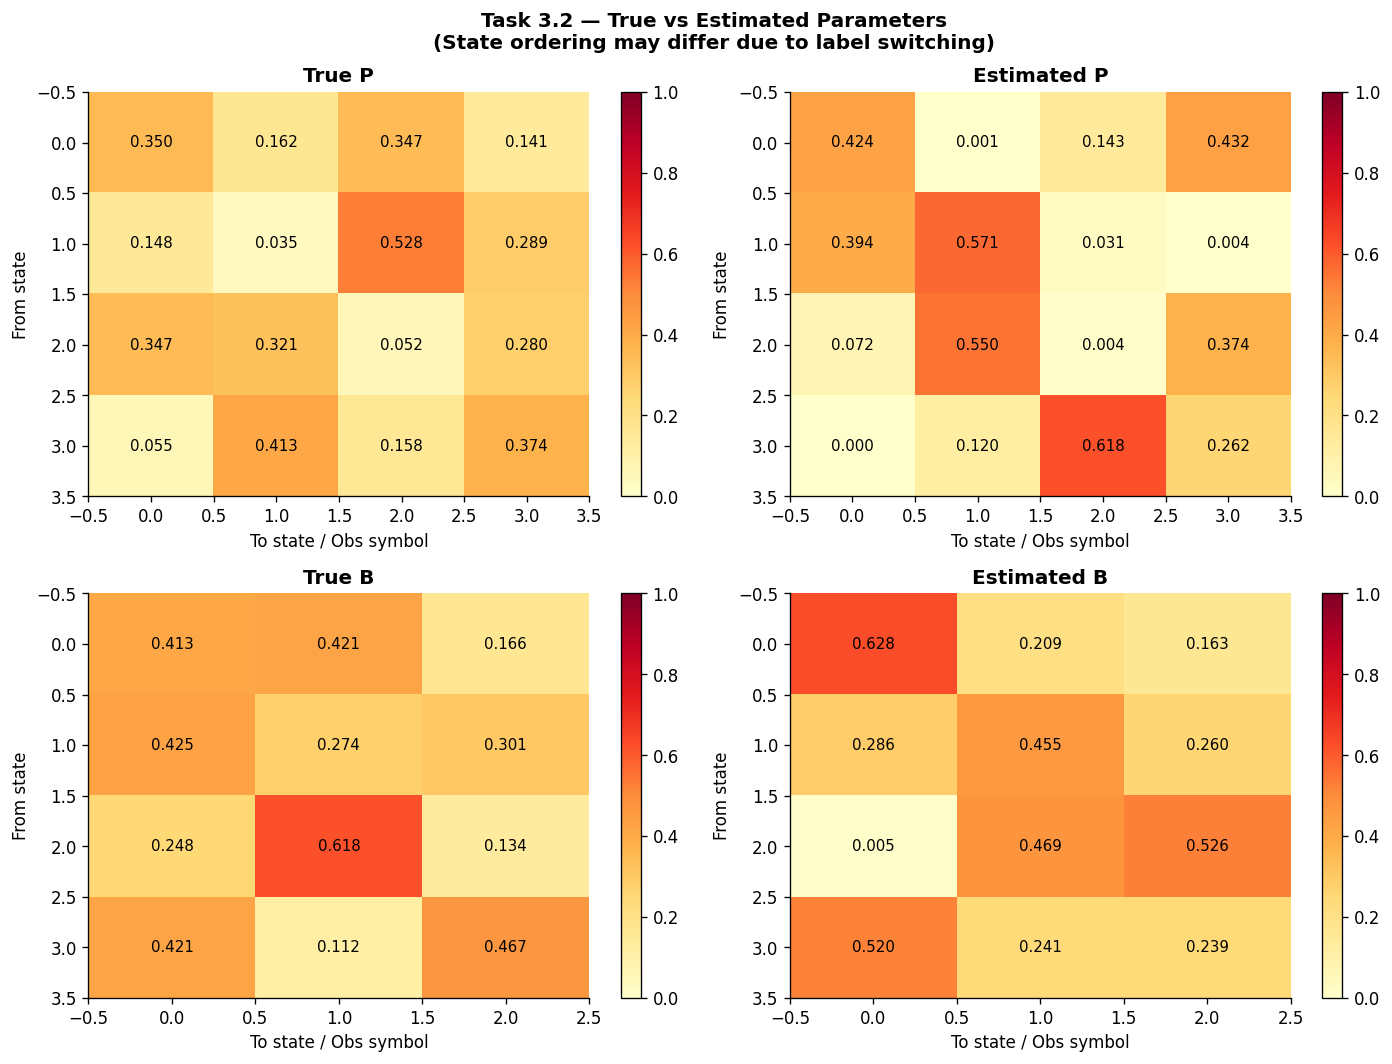

In [8]:
# Heatmap comparison: True vs Estimated
fig, axes = plt.subplots(2,2,figsize=(12,9))
for ax,(mat,title) in zip(axes.flatten(),
                          [(P,'True P'),(P_est,'Estimated P'),(B,'True B'),(B_est,'Estimated B')]):
    im = ax.imshow(mat, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j,i,f'{mat[i,j]:.3f}',ha='center',va='center',
                    fontsize=9,color='black' if mat[i,j]<0.7 else 'white')
    ax.set_title(title,fontweight='bold',fontsize=12)
    ax.set_xlabel('To state / Obs symbol'); ax.set_ylabel('From state')

fig.suptitle('Task 3.2 — True vs Estimated Parameters\n(State ordering may differ due to label switching)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('t3_param_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## Discussion

### p(O|λ) — Forward Algorithm
The forward algorithm computes log p(O|λ) by summing over all possible hidden state paths using the recursion. Log-scale arithmetic prevents numerical underflow. The resulting probability reflects how well the HMM's structure matches the repeating 4-symbol pattern in O = {1,2,3,3,...}.
A higher log p(O|λ) indicates that the observed sequence is more likely under the given HMM.

### Viterbi — Most Probable State Sequence
Viterbi finds Q* = argmax_Q P(Q,O|λ) by dynamic programming, tracking the maximum-probability path rather than summing over all paths. The backtracking step recovers the most likely state at each time step. States with high emission probability for the observed symbol at that time step are preferred in Q*.

### Baum-Welch Training
The Baum-Welch EM algorithm iteratively updates P, B, and π to maximize P(O|λ) over the 1000 training observations. Starting from a random initialization, it converges to a local maximum of the log-likelihood.

### State Label Switching (Important)
The Baum-Welch algorithm learns the HMM parameters up to a permutation of state labels. There is no mechanism that forces 'State 1' in the estimated model to correspond to 'State 1' in the true model. This is the label-switching problem — a fundamental property of mixture models. Therefore, the estimated P and B matrices may appear different from the true ones not because the model failed, but because the state numbering has been permuted. Comparisons should focus on similarity in transition and emission patterns rather than exact row-wise matching.

### p-values
The hmmlearn library does not provide p-values because HMM parameters are constrained probabilities (rows must sum to 1), making standard statistical significance tests inappropriate. Instead, parameter reliability is evaluated using log-likelihood convergence and bootstrap-based confidence intervals. Narrower confidence intervals indicate more stable parameter estimates.

### Estimation accuracy
With 1000 observations and 4 states, Baum-Welch generally provides reasonable estimates of the true parameters after accounting for label switching. States visited more frequently in the training sequence will have better-estimated emission probabilities. The final log-likelihood confirms convergence of the training process. This confirms that the trained model captures the underlying stochastic process that generated the observations.

### Finite Sample Effect
Differences between true and estimated parameters are expected because the model is trained on a finite number of observations (1000 samples). With more data, the estimates would converge closer to the true P and B matrices.